In [1]:
# Import our libraries

# Pandas and numpy for data wrangling
import pandas as pd
import numpy as np

# Seaborn / matplotlib for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Import the trees and model selection / metrics from sklearn
from sklearn import tree
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Helper function to evaluate our model.
def evaluate_model(y_true, y_pred, y_proba=None, pos_label=1):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    print(f"Accuracy Score: {acc:.6f}")
    print(f"Precision Score: {prec:.6f}")
    print(f"Recall Score: {rec:.6f}")
    print(f"F1 Score: {f1:.6f}")
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba)
            print(f"AUC Score: {auc:.6f}")
        except Exception as e:
            print("AUC could not be computed:", e)

# Helper to plot a decision tree
def visualize_tree(model, feature_names, figsize=(12,8)):
    plt.figure(figsize=figsize)
    plot_tree(model, feature_names=feature_names, filled=True, rounded=True, fontsize=10)
    plt.show()

# Use inline so our visualizations display in notebook
%matplotlib inline

## Main Steps when building a Machine Learning Model. 
1. Inspect and explore data.
2. Select and engineer features.
3. Build and train model.
4. Evaluate model.

# #1 Inspect and explore data.
* Load titanic data
* Visualize all the data using sns.pairplot
* Check for null values

In [2]:
# Load in the titanic data set.
# We'll use seaborn's built-in titanic dataset which is reliable for this exercise.
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Text(0.5, 1.02, 'Pairplot of selected numeric columns')

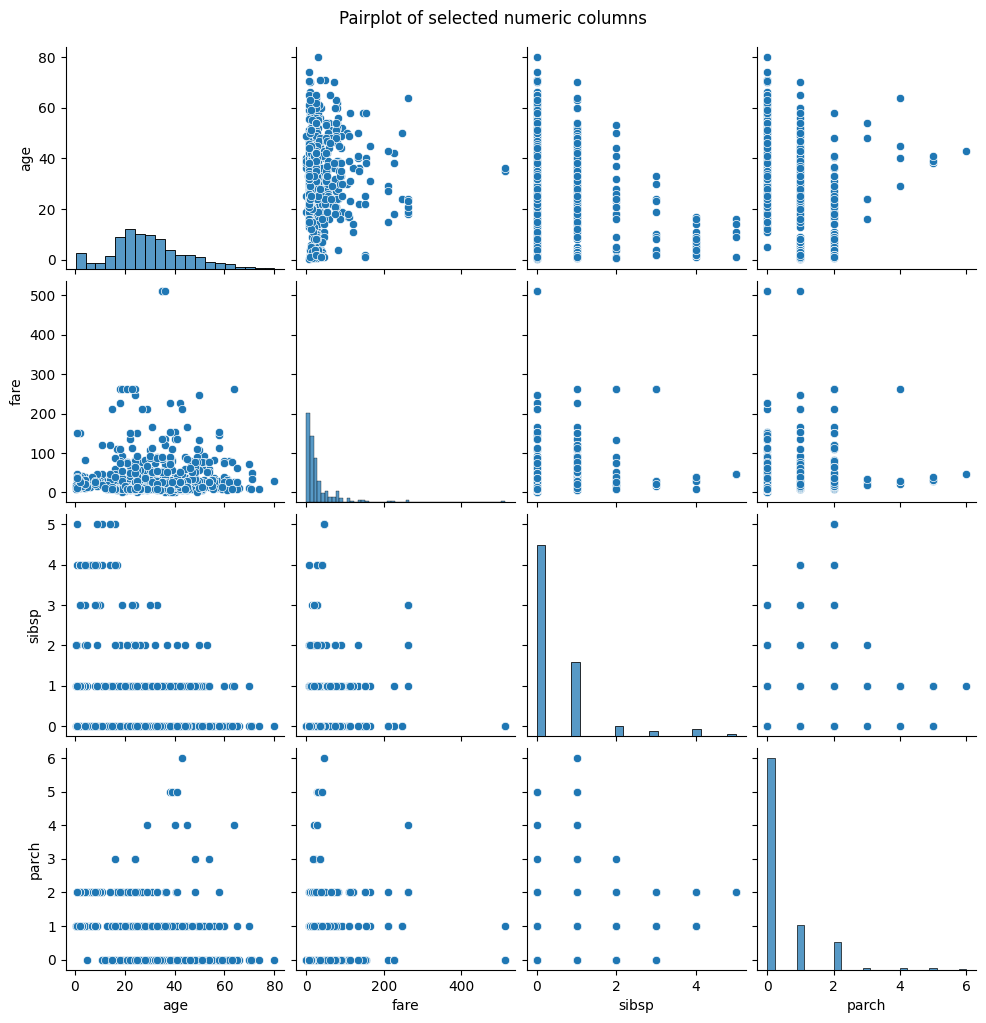

In [3]:
# Visualize all the data using sns.pairplot
# We'll pick a subset of numeric columns for clarity
numeric_cols = ['age', 'fare', 'sibsp', 'parch']
# pairplot can be heavy; limit to a sample to keep the notebook responsive
sns.pairplot(df[numeric_cols].dropna().sample(frac=1.0, random_state=42))
plt.suptitle('Pairplot of selected numeric columns', y=1.02)

In [4]:
# Check for null values
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


# #2 Select and engineer features.
1. Fill age null values with -999
1. Convert to numerical values if need be by using `pd.get_dummies()`
1. Create a list of the features you are going to use.  In this case use as many or as little as you would like.
1. Define our `X` and `y`
1. Split our data into trainig and testing sets.

In [5]:
# Fill age null values with -999 (as instructed)
# We'll operate on a copy to be safe
df2 = df.copy()
df2['age'] = df2['age'].fillna(-999)

df2['age'].describe()

count    891.000000
mean    -174.655253
std      410.873196
min     -999.000000
25%        6.000000
50%       24.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64

In [6]:
# 1. Convert to numerical values if need be by using `pd.get_dummies()`
# We'll encode a few categorical columns: sex, embarked, and class
cat_cols = ['sex','embarked','class']
dummies = pd.get_dummies(df2[cat_cols], drop_first=True)
# concatenate dummies back
df2 = pd.concat([df2.drop(columns=cat_cols), dummies], axis=1)

df2.head()

,survived,pclass,age,sibsp,parch,fare,who,adult_male,deck,embark_town,alive,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third
0,0,3,22.0,1,0,7.2500,man,True,NaN,Southampton,no,False,True,False,True,False,True
1,1,1,38.0,1,0,71.2833,woman,False,C,Cherbourg,yes,False,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,woman,False,NaN,Southampton,yes,True,False,False,True,False,True
3,1,1,35.0,1,0,53.1000,woman,False,C,Southampton,yes,False,False,False,True,False,False
4,0,3,35.0,0,0,8.0500,man,True,NaN,Southampton,no,True,True,False,True,False,True


In [7]:
# 2. Create a list of the features we are going to use.
# We'll pick a reasonable set including pclass, age, sibsp, parch, fare and the dummy columns we created
selected_features = [
    'pclass', 'age', 'sibsp', 'parch', 'fare'
]
# add any dummy columns produced
selected_features += [c for c in df2.columns if c.startswith('sex_') or c.startswith('embarked_') or c.startswith('class_')]

selected_features

['pclass',
 'age',
 'sibsp',
 'parch',
 'fare',
 'sex_male',
 'embarked_Q',
 'embarked_S',
 'class_Second',
 'class_Third']

In [8]:
# Define our `X` and `y`
# target in seaborn titanic is 'survived'
X = df2[selected_features].fillna(-999)
y = df2['survived']

X.shape, y.shape

((891, 10), (891,))

In [9]:
# Split our data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Length of our Training data:', len(X_train), '\nLength of our Testing data:', len(X_test))

Length of our Training data: 712 
Length of our Testing data: 179


# #3 Build and train model.
1. For our first pass, initialize our model with `max_depth=2`.
2. Fit our model with our training data. 
3. Make predictions of our testing data. 
4. Evaluate and print our model scores using accuracy, precision, recall, f1 scores, and auc scores. 
    * To calculate auc score you have to get the predicted probabilites for the Survived class using `model.predict_proba(X_test)[:,1]`
5. Visualize our Decision Tree using provided code. 


In [10]:
# For our first pass, initialize our model with `max_depth=2`.

model = DecisionTreeClassifier(max_depth=2, random_state=42)

In [11]:
# Fit our model with our training data. 
model.fit(X_train, y_train)
print("Model fitted.")

Model fitted.


In [12]:
# Make predictions of our testing data. 
y_pred = model.predict(X_test)
# predicted probabilities for positive class
y_pred_proba = model.predict_proba(X_test)[:,1]

# show a tiny sample of predictions
pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred, 'y_proba': y_pred_proba})[:8]

,y_true,y_pred,y_proba
0,0,0,0.125373
1,0,0,0.125373
2,1,0,0.125373
3,0,0,0.125373
4,1,0,0.500000
5,1,0,0.500000
6,1,1,0.948905
7,0,0,0.346774


Accuracy Score: 0.776536
Precision Score: 0.939394
Recall Score: 0.449275
F1 Score: 0.607843
AUC Score: 0.813307


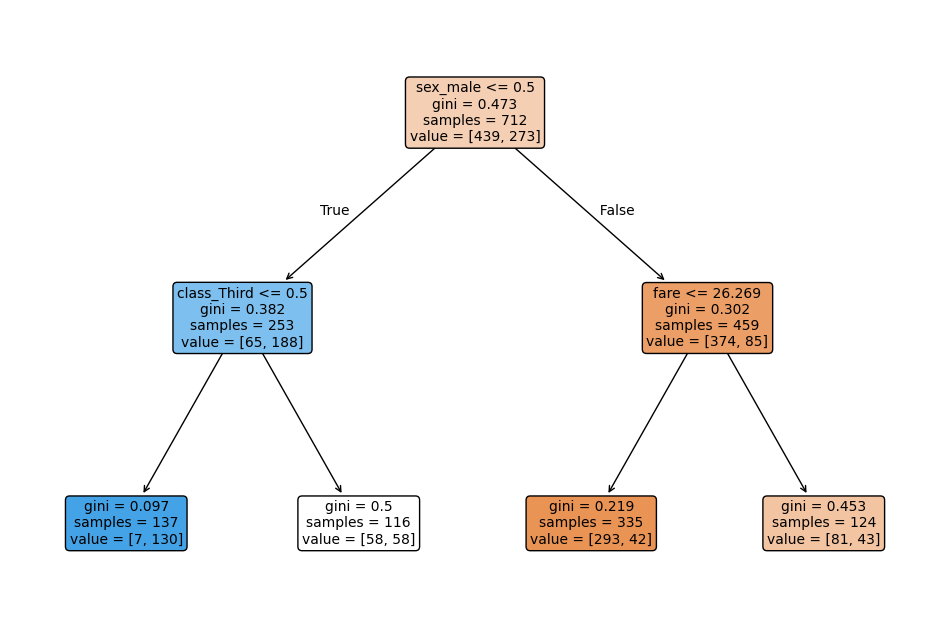

In [13]:
# 4. Evaluate and print our model scores using accuracy, precision, recall, f1 scores, and auc scores. 
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_test, y_pred, zero_division=0)
print("Precision Score: %f" % precision)

recall = recall_score(y_test, y_pred, zero_division=0)
print("Recall Score: %f" % recall)

f1 = f1_score(y_test, y_pred, zero_division=0)
print('F1 Score: %f' % f1)

# Calculate predicted probabilities (we already have them)
y_pred_proba = y_pred_proba

# Compute auc score
auc = roc_auc_score(y_test, y_pred_proba)
print('AUC Score: %f' % auc)

# Visualize the decision tree
visualize_tree(model, feature_names=selected_features)

# Visualize your tree

# Picking the right parameters...

# Parameter tuning of your Decision Tree using GridSearch or RandomizedSearch

### For assistance on this, look at Steves TA Tips code in `TA-Tips/random_forest_tuning.ipynb`


1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
1. Initalize your GridSearchCV with a DecisionTreeClassifier, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
1. Fit your GridSearchCV with your training data. 
1. Print the parameters of your best model. 
1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 
1. Visualize your best tree.
1. Which feature was your most important feature?

```python
tree.DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_impurity_split=None,
    class_weight=None,
    presort='deprecated',
    ccp_alpha=0.0,
)
```


[Tips on how to customize / set the paramters in the decision tree.](https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use)

In [14]:
# 1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search.
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [1, 2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [15]:
# 1. Initalize your GridSearchCV with a DecisionTreeClassifier, your param_grid, and what you are optimizing for.
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), params, scoring='f1', cv=5, n_jobs=-1, verbose=1)

In [16]:
# 1. Fit your GridSearchCV with your training data. 
grid_search_cv.fit(X_train, y_train)
print('Grid search complete')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Grid search complete
Grid search complete


In [17]:
# 1. Print the parameters of your best model. 
# Print the best parameters it found
print(grid_search_cv.best_params_)

{'criterion': 'gini', 'max_depth': 1, 'min_samples_split': 2}


Accuracy Score: 0.776536
Precision Score: 0.737705
Recall Score: 0.652174
F1 Score: 0.692308
AUC Score: 0.753360


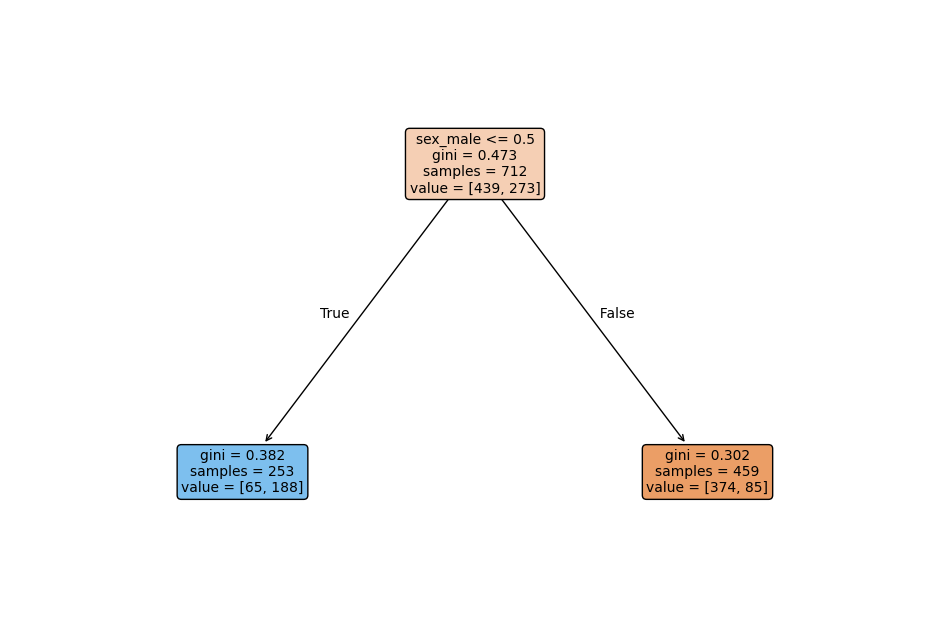

In [18]:
# 1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 

# This command gives you the best tree
best_dt = grid_search_cv.best_estimator_

# Now lets evaluate our model
y_pred = best_dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_test, y_pred, zero_division=0)
print("Precision Score: %f" % precision)

recall = recall_score(y_test, y_pred, zero_division=0)
print("Recall Score: %f" % recall)

f1 = f1_score(y_test, y_pred, zero_division=0)
print('F1 Score: %f' % f1)

# Calculate predicted probabilities, keep only probability for when class = 1
y_pred_proba = best_dt.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_pred_proba)
print('AUC Score: %f' % auc)

# Visualize best tree
visualize_tree(best_dt, feature_names=selected_features)

In [19]:
# 1. Which feature was your most important feature?
# Now lets look at our feature importances
feature_imp = pd.DataFrame.from_dict( {'feature_importance': model.feature_importances_,
                                       'feature':selected_features }).sort_values('feature_importance', ascending=False)
feature_imp

,feature_importance,feature
5,0.748091,sex_male
9,0.186535,class_Third
4,0.065374,fare
0,0.000000,pclass
1,0.000000,age
3,0.000000,parch
2,0.000000,sibsp
6,0.000000,embarked_Q
7,0.000000,embarked_S
8,0.000000,class_Second


# Now onto Random Forests...
Were going to do the same with, but this time with a random forest. Remeber... Repetition is the father of learning.

1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
1. Initalize your GridSearchCV with a RandomForestClassifer, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
1. Fit your GridSearchCV with your training data. 
1. Print the parameters of your best model. 
1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 
1. Which feature was your most important feature?


# Parameters of the Random Forest Classifier

```python
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='auto',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_impurity_split=None,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
)
```

In [20]:
# 1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

In [21]:
# 1. Initalize your GridSearchCV or RandomizedSearchCV with a RandomForestClassifier
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), params, scoring='f1', cv=4, n_jobs=-1, verbose=1)

In [22]:
# 1. Fit your GridSearchCV with your training data. 
rf_grid.fit(X_train, y_train)
print('Random Forest grid search complete')

Fitting 4 folds for each of 27 candidates, totalling 108 fits
Random Forest grid search complete
Random Forest grid search complete


In [23]:
# 1. Print the parameters of your best model. 
# Print the best parameters it found
print(rf_grid.best_params_)

# store best model
best_rf = rf_grid.best_estimator_

{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}


In [24]:
# 1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 

#This command gives you tree that has the highest f1-score. 
model = best_rf

# Now lets evaluate our model
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_test, y_pred, zero_division=0)
print("Precision Score: %f" % precision)

recall = recall_score(y_test, y_pred, zero_division=0)
print("Recall Score: %f" % recall)

f1 = f1_score(y_test, y_pred, zero_division=0)
print('F1 Score: %f' % f1)

# Calculate predicted probabilities, keep only probability for when class = 1
y_pred_proba = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_pred_proba)
print('AUC Score: %f' % auc)

# Show feature importances
feature_imp = pd.Series(model.feature_importances_,index=selected_features).sort_values(ascending=False)
feature_imp

Accuracy Score: 0.798883
Precision Score: 0.761905
Recall Score: 0.695652
F1 Score: 0.727273
AUC Score: 0.842424


sex_male        0.293433
fare            0.241917
age             0.198505
pclass          0.055559
parch           0.055031
class_Third     0.052697
sibsp           0.048703
embarked_S      0.029788
embarked_Q      0.013635
class_Second    0.010732
dtype: float64

In [ ]:
# 1. Which feature was your most important feature?
# Now lets look at our feature importances
feature_imp = pd.Series(model.feature_importances_,index=selected_features).sort_values(ascending=False)
feature_imp

# Build a random forest using the ny-vs-sf-housing.csv data. 
* Your target variable, aka the column you are trying to predict, aka your `y` variable is `in_sf`. 
* Can you get an accuracy above %88.8889?
* What was your most important feature?


In [27]:
df = pd.read_csv('../data/ny-vs-sf-houses.csv')
df.head()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
0,0,2.0,1.0,999000,1960,1000,999,10
1,0,2.0,2.0,2750000,2006,1418,1939,0
2,0,2.0,2.0,1350000,1900,2150,628,9
3,0,1.0,1.0,629000,1903,500,1258,9
4,0,0.0,1.0,439000,1930,500,878,10


In [29]:
# BUILD, TRAIN, AND EVAULATE A RANDOM FOREST MODEL BELOW. 
# We'll do a simple preprocessing: drop rows with all-null, fill numeric NaN with median,
# encode categoricals with get_dummies, and train a RandomForest to predict 'in_sf'.

nydf = df.copy()

# Quick cleanup: drop columns with too many nulls (>80%)
thresh = int(0.2 * len(nydf))
nydf = nydf.dropna(axis=1, thresh=thresh)

# Separate target
if 'in_sf' not in nydf.columns:
    raise ValueError("Expected column 'in_sf' in ny-vs-sf-houses.csv")

# Fill numerics and dummy encode categoricals
num_cols = nydf.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in nydf.columns if c not in num_cols and c != 'in_sf']

for c in num_cols:
    nydf[c] = nydf[c].fillna(nydf[c].median())

nydf = pd.get_dummies(nydf, columns=cat_cols, drop_first=True)

X_ny = nydf.drop(columns=['in_sf'])
y_ny = nydf['in_sf']

# Train/test split
Xn_train, Xn_test, yn_train, yn_test = train_test_split(X_ny, y_ny, test_size=0.2, random_state=42, stratify=y_ny)

# Train a RandomForest with reasonable defaults
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(Xn_train, yn_train)

# Evaluate
yn_pred = rf.predict(Xn_test)
print('NY vs SF RandomForest results:')
evaluate_model(yn_test, yn_pred)

# Feature importances (top 10)
fi = pd.Series(rf.feature_importances_, index=X_ny.columns).sort_values(ascending=False)
fi.head(10)

NY vs SF RandomForest results:
Accuracy Score: 0.898990
Precision Score: 0.892857
Recall Score: 0.925926
F1 Score: 0.909091


elevation         0.334038
price_per_sqft    0.249403
sqft              0.114077
price             0.110350
year_built        0.104812
beds              0.056183
bath              0.031137
dtype: float64

# Awesome difficult extra credit below:
Build a classifier using the adult_income.csv data.  
* The target variable is 'class'
* Start with just using these features `selected_features = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']`
* You have to include the pos_label in your precision, recall, and f1 scores. It just tells the classifier which one is the posotive label.  I provided the proper way below.

* See if you can get above 50% f1 score.  
* See some [super tricks and tips here](https://www.kaggle.com/code/jieyima/income-classification-model)

In [31]:
df = pd.read_csv('../data/adult_income.csv')
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [33]:
# Build a classifier using the adult_income.csv data.
# Start with only the specified features and the target 'class'.

adult = df.copy()
selected_features = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']

# Keep only selected features and drop rows with missing target
adult = adult.dropna(subset=['class'])
X_adult = adult[selected_features].fillna(0)
# Convert target to 0/1 if necessary
if adult['class'].dtype == 'object':
    y_adult = adult['class'].apply(lambda v: 1 if str(v).strip().endswith('>50K') or str(v).strip()=='>50K' else 0)
else:
    y_adult = adult['class']

# Quick train/test split
Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_adult, y_adult, test_size=0.2, random_state=42, stratify=y_adult)

# Train a small RandomForest for this exercise
rf_adult = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_adult.fit(Xa_train, ya_train)

# Predict and evaluate
ya_pred = rf_adult.predict(Xa_test)
ya_proba = rf_adult.predict_proba(Xa_test)[:,1]

# When computing precision/recall/f1 we must provide pos_label if using non-binary; here pos_label=1
print('Adult income classifier metrics:')
evaluate_model(ya_test, ya_pred, y_proba=ya_proba, pos_label=1)

Adult income classifier metrics:
Accuracy Score: 0.776908
Precision Score: 0.542687
Recall Score: 0.466199
F1 Score: 0.501544
AUC Score: 0.773462
